In [11]:
from pandas import read_csv
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [10]:
df = read_csv("../../datasets/spambase.csv")

x = df[['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',
       'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
       'char_freq_$', 'char_freq_#', 'capital_run_length_average',
       'capital_run_length_longest', 'capital_run_length_total']].values

y = np.asarray(df['spam'].values)

x = preprocessing.StandardScaler().fit(x).transform(x)

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)


training data:  (3680, 57) (3680,)
testing data:  (921, 57) (921,)


In [83]:
# lg = LogisticRegression(C=0.01, solver='newton-cholesky', penalty=None).fit(x_train, y_train)
lg = LogisticRegression(C=0.01, solver='newton-cg', penalty=None).fit(x_train, y_train) # 23, 42
lg


C:\Users\SADAF COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


LogisticRegression(C=0.01, penalty=None, solver='newton-cg')

In [84]:
yhat = lg.predict(x_test)

print(metrics.classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       562
           1       0.93      0.88      0.91       359

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



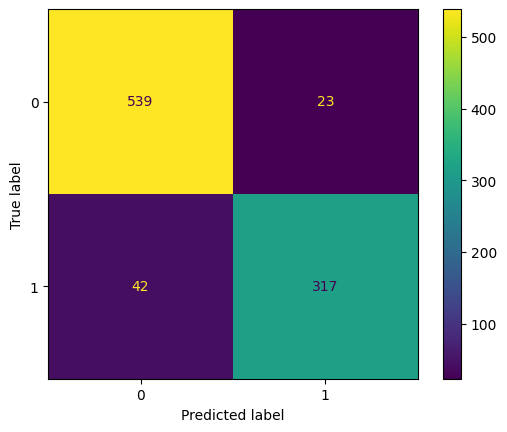

In [85]:
cm = metrics.confusion_matrix(y_test, yhat)
disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()
# you can see KNN classification shows better results for this dataset!